# Estatística Descritiva - Estimativas de Variabilidade

**Objetivos da Aula - Estimativas de Variabilidade**

* Compreender o conceito de **variabilidade** em conjunto de dados.
* Calcular e interpretar **variância** e **desvio-padrão**.
* Entender medidas baseadas em **desvios absolutos** (MAD).
* Identificar **medidas de dispersão simpes**, como **amplitude**
* Compreender **estatísticas ordinais**, como **percentis** e **quartis**.
* Calcular e interpretar o **intervalo interquartil (IQR)**.
* Analisar como diferentes medidas descrevem o **espalhamento dos dados**.
* Aplicar essas medidas usando **Python e Jupyter**.

---

Na aula anterior aprendemos **estimativas de localização**:
- média
- mediana

Essas medidas dizem **onde os dados estão**.

Agora vamos estudar **estimativas de variabilidade**, que respondem:

> **O quanto os dados se espalham?**

Mesmo com a mesma média, conjuntos de dados podem ter **variabilidade muito diferente**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Dois conjuntos com a mesma média

In [2]:
dados_A = np.array([10, 10, 10, 10, 10, 10, 10])
dados_B = np.array([5, 7, 9, 10, 11, 13, 15])

print(f"Média de A: {dados_A.mean()}\nMédia de B: {dados_B.mean()}")

Média de A: 10.0
Média de B: 10.0


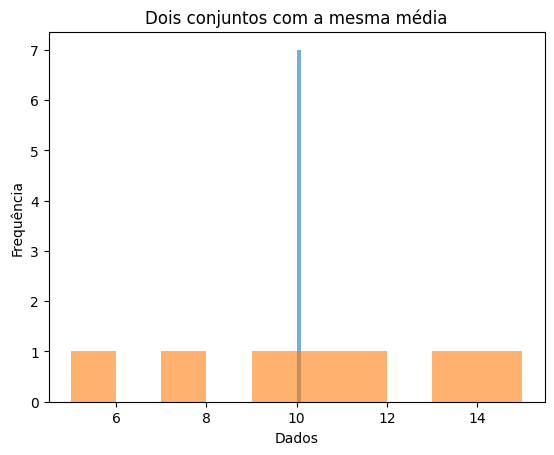

In [3]:
plt.figure()
plt.hist(dados_A, alpha=0.6)
plt.hist(dados_B, alpha=0.6)
plt.title("Dois conjuntos com a mesma média")
plt.ylabel("Frequência")
plt.xlabel("Dados")
plt.show()

## Desvio
O **desvio** é a diferença entre um valor observador e uma estimativa de localização (geralmente a média)

Fórmula:

`desvio = valor_observador - média`

In [4]:
media = dados_B.mean()

desvios = dados_B - media

print(f"Desvios: {desvios}")

Desvios: [-5. -3. -1.  0.  1.  3.  5.]


In [5]:
print(desvios.sum())

0.0


## Variância

A variância mede o espalhamento dos dados.

Ela é calcula como:

`S² = soma dos quadrados dos desvios / (n - 1)`

Usamos n-1 para corrigir o viés da amostra.

In [6]:
np.var(dados_B, ddof=1)

11.666666666666666

In [7]:
((dados_B - dados_B.mean())**2).sum() / (len(dados_B)-1)

11.666666666666666

## Desvio-Padrão

O desvio-padrão é simplesmente a **raiz quadrada da variância**.

Ele é mais interpretável porque está na **mesma unidade de dados**.

In [8]:
# Standard Deviation ~ Desvio-Padrão
np.std(dados_B, ddof=1)

3.415650255319866

* variância -> unidades ao quadrado
* desvio padrão -> mesma unidade original
* mede o espalhamento dos dados, mas **dando mais peso a valores muito distantes**.
* Ou seja:
  - pequenas variações -> impacto pequeno
  - grandes variações -> impacto grande
> medida de espalhamento que penaliza valores muito distantes da média.
>
> espalhamento com penalização de extremos.

## Desvio Absoluto Médio

É a média dos valores absolutos dos desvios a média.

`MAD = média (|valor - média|)`

In [9]:
np.mean(np.abs(dados_B - dados_B.mean()))

2.5714285714285716

* usa valores absolutos
* menos sensível que variância
* mas ainda depende da média
* em média, os valores estão 2.57 distantes da média
* mede a distância média até a média.
* é como perguntar: "Em média, quanto cada valor se afasta do centro?"

> distância média da média
> 
> distância média até o centro

* é mais robusta contra **outliers**

## Amplitude

A amplitude é a diferença entre o maior e o menor valor.

`Amplitude = máximo - mínimo`

In [10]:
dados_B.max() - dados_B.min()

10

* muito simples
* depende apenas de dois valores

## Estatísticas Ordinais

São métricas baseadas na **ordenação dos dados**.

Exemplos:
- mediana
- quartis
- percentis

In [11]:
np.sort(dados_B)

array([ 5,  7,  9, 10, 11, 13, 15])

## Percentil 

O percentil P indica que **P% dos valores estão abaixo dele**.

* `np.percentile(dados_B, 25)` 25º percentil ou 1º quartil
* `np.percentile(dados_B, 50)` 50º percentil ou 2º quartil ou mediana
* `np.percentile(dados_B, 75)` 75º percentil ou 3º quartil

## Intervalo Interquartil (IQR)

IQR = Q3 - Q1

Ele mede a dispersão da parte **central dos dados**.

In [12]:
q1 = np.percentile(dados_B, 25)
q3 = np.percentile(dados_B, 75)

iqr = q3 - q1
iqr

4.0

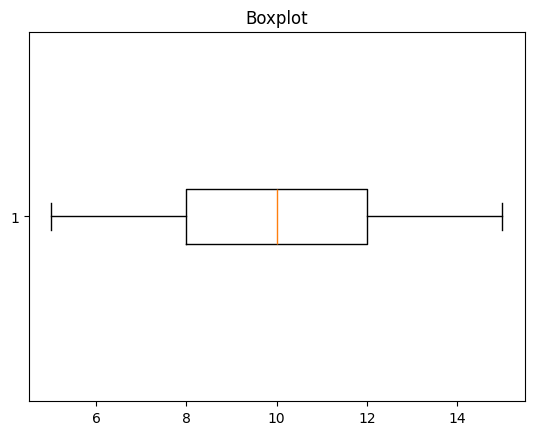

In [13]:
plt.figure()
plt.boxplot(dados_B, vert=False)
plt.title("Boxplot")
plt.show()

# Exercícios

## 1 (interpretação)
`x = np.array([10, 12, 11, 13, 12, 11, 50])`

* Tarefas:
  - média
  - variância
  - desvio padrão
* Calcule
  - mediana
  - MAD
* Pergunta:
> Qual medida de variabilidade foi mais afetada pelo outlier?

## Exercício 2

`y = np.array([5, 7, 8, 9, 10, 11, 12, 14, 15])`

Calcule
* amplitude
* Q1
* Q3
* IQR
Faça também:
`plt.boxlot(y)`

## Exercício 3

`latencia = np.array([120, 125, 130, 118, 119, 122, 500])`

Perguntas:
* Qual é o desvio padrão?
* Qual é o IQR?
* Qual medida parece **mais robustas**?

## Fechamento
### Resumo
Estimativas de variabilidade medem **o quanto os dados se espalham**.

Principais medidas:
- variância
- desvio padrão
- desvio absoluto médio
- MAD da mediana
- Amplitude
- IQR

> Em ciência de dados, medidas **robustas** como **mediana e IQR** são muito úteis quando há outliers.